# single linkage

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [18]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Perform agglomerative clustering
n_clusters = 2  # We know there are 2 classes in the breast cancer dataset
agg_clustering1 = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
agg_clustering2 = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
agg_clustering3 = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')


cluster_labels1 = agg_clustering1.fit_predict(X_scaled)
cluster_labels2 = agg_clustering2.fit_predict(X_scaled)
cluster_labels3 = agg_clustering3.fit_predict(X_scaled)

In [21]:
pca

PCA(n_components=2)

In [22]:


# Evaluate the clustering performance
print("Clustering Performance Metrics:")
print(f"Single linkage Silhouette Score: {silhouette_score(X_scaled, cluster_labels1):.4f}")

print(f"Avarage linkage Silhouette Score: {silhouette_score(X_scaled, cluster_labels2):.4f}")

print(f"Complate linkage Silhouette Score: {silhouette_score(X_scaled, cluster_labels3):.4f}")

Clustering Performance Metrics:
Single linkage Silhouette Score: 0.6607
Avarage linkage Silhouette Score: 0.6340
Complate linkage Silhouette Score: 0.6607


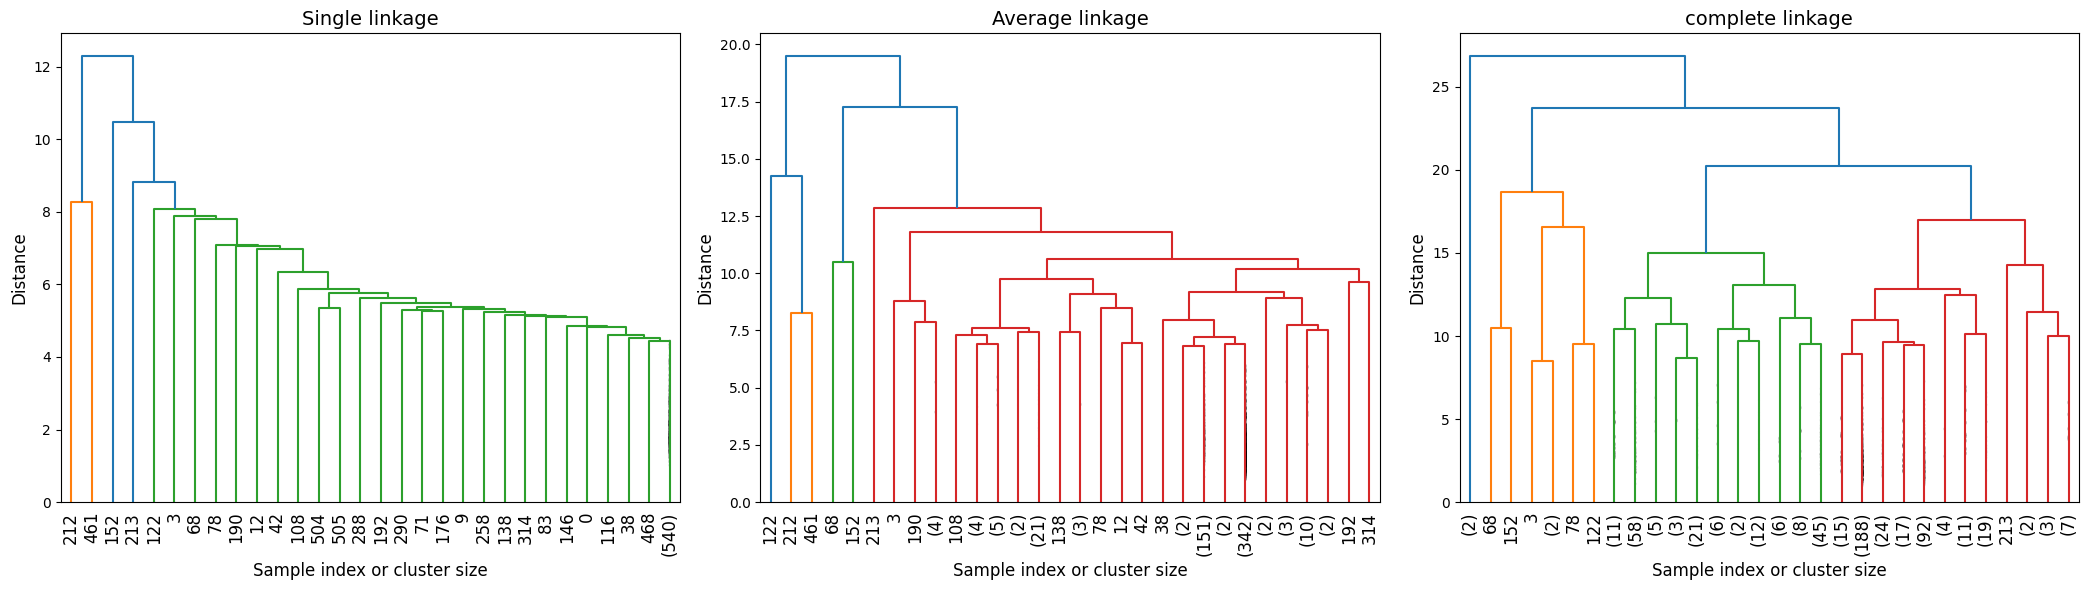

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

methods = ['single',          'average',          'complete'         ]
titles  = ['Single linkage',   'Average linkage',  'complete linkage'  ]

for ax, method, title in zip(axes, methods, titles):
    plt.sca(ax)                               # set current axis
    Z = linkage(X_scaled, method=method)      # different Z each time
    dendrogram(
        Z,
        truncate_mode='lastp', p=30,
        leaf_rotation=90., leaf_font_size=12.,
        show_contracted=True
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Sample index or cluster size', fontsize=12)
    ax.set_ylabel('Distance', fontsize=12)

plt.tight_layout()
plt.show()